# Part 1: Expectation-Maximization (EM) Algorithm

## Objective

The objective of this notebook is to implement the Expectation-Maximization (EM) algorithm from scratch to separate a mixed dataset of Father and Child heights into two Gaussian distributions without using their labels.

The implementation follows the mathematical steps of the EM algorithm:

- Load and mix the dataset
- Initialize model parameters
- Compute Gaussian probabilities
- Perform the Expectation (E-Step)
- Perform the Maximization (M-Step)
- Calculate Log-Likelihood
- Repeat until convergence
- Predict the probability that a random height belongs to a Father or a Child

## Dataset

The Galton Families dataset contains measurements of family members' heights.

For this assignment, we selected:

- Father Heights
- Child Heights

The two groups are combined into a single dataset and shuffled so that the original labels are hidden. This simulates a real-world clustering problem where class labels are unknown.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:

# Load dataset


df = pd.read_csv('/content/GaltonFamilies.csv')
print(df.head())

   rownames family  father  mother  midparentHeight  children  childNum  \
0         1    001    78.5    67.0            75.43         4         1   
1         2    001    78.5    67.0            75.43         4         2   
2         3    001    78.5    67.0            75.43         4         3   
3         4    001    78.5    67.0            75.43         4         4   
4         5    002    75.5    66.5            73.66         4         1   

   gender  childHeight  
0    male         73.2  
1  female         69.2  
2  female         69.0  
3  female         69.0  
4    male         73.5  


In [ ]:

# Mix dataset (For having a new dataset with no structure relation with the original one)

father = df['father'].to_numpy()
children = df['childHeight'].to_numpy()

heights = np.concatenate((father, children))

np.random.seed(42)
np.random.shuffle(heights)

print(heights[:10])

[70.2 62.  64.  70.  69.  71.5 70.  70.5 70.  71. ]


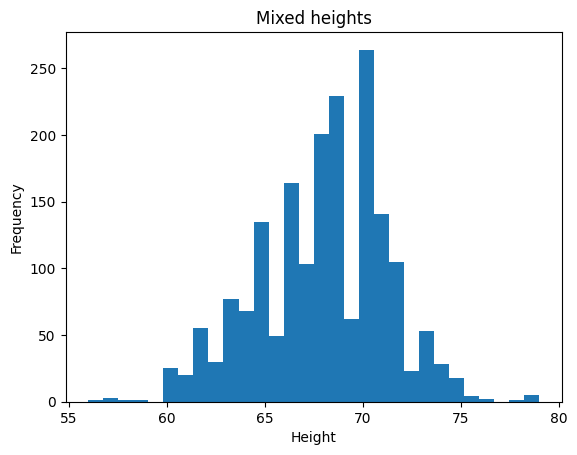

In [ ]:

# Visualize data

plt.hist(heights, bins=30)
plt.xlabel('Height')
plt.ylabel('Frequency')
plt.title('Mixed heights')
plt.show()

In [ ]:
#==========================
# Initialize parameters (Guess initial parameters for the EM algorithm / Mean / Variance / Mixing coefficients)
#==========================

mu1 = np.percentile(heights, 25)
mu2 = np.percentile(heights, 75)

sigma1 = np.std(heights)
sigma2 = np.std(heights)

pi1 = 0.5
pi2 = 0.5

print(mu1)
print(mu2)
print(sigma1)
print(sigma2)
print(pi1)
print(pi2)

66.0
70.0
3.31118124589431
3.31118124589431
0.5
0.5


## Gaussian (Normal) Distribution

The EM algorithm assumes that each population follows a Gaussian distribution.

The Gaussian Probability Density Function (PDF) is

\[
f(x)=\frac{1}{\sqrt{2\pi\sigma^2}}
\exp\left(-\frac{(x-\mu)^2}{2\sigma^2}\right)
\]

where

- μ = Mean
- σ = Standard Deviation

The PDF computes how likely a particular height belongs to a Gaussian distribution.

In [ ]:

# Build Gaussian function (Probability Density Function Equation)

def gaussian(data, mu, sigma):
    coefficient = 1 / (np.sqrt(2 * np.pi) * sigma)
    exponent = np.exp(-((data - mu) ** 2) / (2 * sigma ** 2))
    return coefficient * exponent

## Expectation Step (E-Step)

During the Expectation Step, the algorithm computes the posterior probability (responsibility) that every height belongs to each Gaussian distribution.

For every observation, we calculate

- Probability of belonging to Gaussian 1
- Probability of belonging to Gaussian 2

The responsibilities always sum to 1.

These probabilities are later used to update the model parameters.

In [ ]:
# Implement E-step
def expectation_step(data, mu1, mu2, sigma1, sigma2, pi1, pi2):

    # Probability under Gaussian 1 (Children)
    prob1 = pi1 * gaussian(data, mu1, sigma1)

    # Probability under Gaussian 2 (Fathers)
    prob2 = pi2 * gaussian(data, mu2, sigma2)

    # Total probability
    total = prob1 + prob2

    # Responsibilities
    r1 = prob1 / total
    r2 = prob2 / total

    return r1, r2

## Maximization Step (M-Step)

During the Maximization Step, the parameters of each Gaussian distribution are updated using the responsibilities computed during the E-Step.

The updated parameters include

- Mean (μ)
- Standard Deviation (σ)
- Mixing Coefficient (π)

These updated values better describe the two hidden populations.

In [ ]:
# Implement M-step

def maximization_step(data, r1, r2):

    mu1 = np.sum(r1 * data) / np.sum(r1)
    mu2 = np.sum(r2 * data) / np.sum(r2)

    sigma1 = np.sqrt(
        np.sum(r1 * (data - mu1) ** 2) / np.sum(r1)
    )

    sigma2 = np.sqrt(
        np.sum(r2 * (data - mu2) ** 2) / np.sum(r2)
    )

    pi1 = np.mean(r1)
    pi2 = np.mean(r2)

    return mu1, mu2, sigma1, sigma2, pi1, pi2

## Log-Likelihood

The Log-Likelihood measures how well the current Gaussian distributions explain the observed data.

After every iteration, the Log-Likelihood should increase (or become less negative).

When the Log-Likelihood no longer changes significantly, the EM algorithm has converged.

In [ ]:
# Compute log-likelihood
def log_likelihood(data, mu1, mu2, sigma1, sigma2, pi1, pi2):

    likelihood = (
        pi1 * gaussian(data, mu1, sigma1)
        +
        pi2 * gaussian(data, mu2, sigma2)
    )

    likelihood = np.clip(likelihood, 1e-12, None)

    return np.sum(np.log(likelihood))

In [ ]:
#==========================
# Run EM loop (For iteratively performing the E-step and M-step until convergence)
#==========================

max_iterations = 100
tolerance = 1e-6

previous_ll = -np.inf

print(
    f"{'Iter':<5}"
    f"{'μ1':>10}"
    f"{'μ2':>10}"
    f"{'σ1²':>10}"
    f"{'σ2²':>10}"
    f"{'π1':>10}"
    f"{'π2':>10}"
    f"{'LogLik':>15}"
)

for iteration in range(max_iterations):

    # E-Step
    r1, r2 = expectation_step(
        heights,
        mu1,
        mu2,
        sigma1,
        sigma2,
        pi1,
        pi2
    )

    # M-Step
    mu1, mu2, sigma1, sigma2, pi1, pi2 = maximization_step(
        heights,
        r1,
        r2
    )

    # Log Likelihood
    ll = log_likelihood(
        heights,
        mu1,
        mu2,
        sigma1,
        sigma2,
        pi1,
        pi2
    )

    # Check for convergence
    if abs(ll - previous_ll) < tolerance:
        print(f"Converged after {iteration} iterations.")
        break

    previous_ll = ll

    print(
        f"{iteration:<5}"
        f"{mu1:>10.2f}"
        f"{mu2:>10.2f}"
        f"{sigma1**2:>10.2f}"
        f"{sigma2**2:>10.2f}"
        f"{pi1:>10.3f}"
        f"{pi2:>10.3f}"
        f"{ll:>15.2f}"
    )

Iter         μ1        μ2       σ1²       σ2²        π1        π2         LogLik
0         66.40     69.52      9.70      7.39     0.497     0.503       -4873.52
1         66.37     69.53     10.23      6.75     0.494     0.506       -4869.37
2         66.34     69.55     10.49      6.37     0.492     0.508       -4867.63
3         66.32     69.57     10.61      6.10     0.492     0.508       -4866.74
4         66.30     69.59     10.65      5.91     0.492     0.508       -4866.21
5         66.28     69.62     10.66      5.77     0.493     0.507       -4865.85
6         66.27     69.64     10.64      5.66     0.495     0.505       -4865.59
7         66.26     69.66     10.61      5.57     0.496     0.504       -4865.38
8         66.25     69.68     10.57      5.50     0.498     0.502       -4865.21
9         66.24     69.70     10.53      5.44     0.500     0.500       -4865.07
10        66.24     69.71     10.49      5.39     0.502     0.498       -4864.94
11        66.24     69.73   

## Height Classification

After training, the model can classify any new height.

Instead of making a hard decision, the model computes

- Probability the height belongs to a Child
- Probability the height belongs to a Father

The class with the highest posterior probability becomes the prediction.

In [ ]:

# Random heights

height = float(input("Enter a height: "))

def classify_height(height, mu1, mu2, sigma1, sigma2, pi1, pi2):

    p1 = pi1 * gaussian(height, mu1, sigma1)
    p2 = pi2 * gaussian(height, mu2, sigma2)

    total = p1 + p2

    child_probability = p1 / total
    father_probability = p2 / total

    print(f"Height: {height:.2f}")
    print(f"Probability Child : {child_probability:.4f}")
    print(f"Probability Father: {father_probability:.4f}")

    if child_probability > father_probability:
        print("Prediction: Child")
    else:
        print("Prediction: Father")

classify_height(
    height,
    mu1,
    mu2,
    sigma1,
    sigma2,
    pi1,
    pi2
)

Enter a height: 1.85
Height: 1.85
Probability Child : 1.0000
Probability Father: 0.0000
Prediction: Child


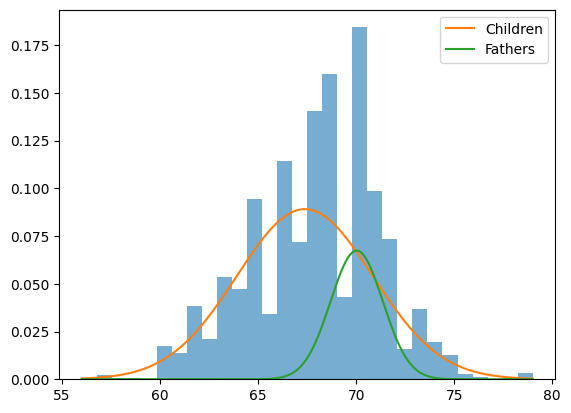

In [ ]:

# Plot the final Gaussian distributions after EM convergence


x = np.linspace(min(heights), max(heights), 500)

plt.hist(heights, bins=30, density=True, alpha=0.6)

plt.plot(x, pi1 * gaussian(x, mu1, sigma1), label="Children")
plt.plot(x, pi2 * gaussian(x, mu2, sigma2), label="Fathers")

plt.legend()
plt.show()

## Why Should We Not Split the Dataset at the Global Mean?

Splitting the dataset at the global mean assumes that every observation below the mean belongs to one group and every observation above the mean belongs to the other.

This approach ignores the fact that the two Gaussian distributions overlap.

Many heights near the center could reasonably belong to either Fathers or Children.

The Expectation-Maximization algorithm instead computes posterior probabilities for every observation, allowing uncertain observations to partially belong to both groups during training.

This probabilistic approach produces a much more accurate model than using a fixed threshold at the global mean.

# Part 2: Bayesian Probability

## Objective

The objective of this notebook is to implement Bayes' Theorem using the IMDb Movie Reviews Dataset.

The goal is to compute the probability that a review is positive given that it contains a particular keyword.


In [ ]:
import pandas as pd

In [ ]:

# Load dataset

df = pd.read_csv('/content/IMDB Dataset.csv')

print(df.head())

                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive


In [ ]:

# Count total reviews


total_reviews = len(df)

print(total_reviews)

50000


In [ ]:

# Count positive reviews

positive_reviews = len(
    df[df["sentiment"] == "positive"]
)

print(positive_reviews)

25000


## Bayes' Theorem

Bayes' Theorem is

\[
P(A|B)=
\frac{P(B|A)P(A)}
{P(B)}
\]

For this project

A = Positive Review

B = Keyword

Therefore,

\[
P(\text{Positive}|\text{Keyword})
=
\frac{
P(\text{Keyword}|\text{Positive})
P(\text{Positive})
}
{
P(\text{Keyword})
}
\]

## Prior Probability

The Prior Probability represents the probability that any randomly selected review is positive.

\[
P(\text{Positive})
=
\frac{\text{Positive Reviews}}
{\text{Total Reviews}}
\]

In [ ]:

# Count the prior (P(positive))


prior = positive_reviews / total_reviews

print(prior)

0.5


## Likelihood

The Likelihood measures the probability that a positive review contains the selected keyword.

\[
P(\text{Keyword}|\text{Positive})
=
\frac{
\text{Positive Reviews Containing Keyword}
}
{
\text{Positive Reviews}
}
\]

In [ ]:
#===================
# Choose a keyword
#===================

keyword = "excellent"

In [ ]:
#===============================
# Count positive with keyword (P(keyword | positive))
#===============================

positive_keyword = df[
    (df["sentiment"] == "positive")
    &
    (
        df["review"]
        .str.lower()
        .str.contains(keyword)
    )
]
positive_keyword_count = len(positive_keyword)

print(f"Count of positive reviews containing '{keyword}': {positive_keyword_count}")

Count of positive reviews containing 'excellent': 2936


In [ ]:
#===============================
# Count the likelihood (P(keyword | positive)) Positive reviews with keyword / Total positive reviews
#===============================

likelihood = positive_keyword_count / positive_reviews

print(f"Likelihood of '{keyword}' given positive sentiment: {likelihood}")

Likelihood of 'excellent' given positive sentiment: 0.11744


## Marginal Probability

The Marginal Probability measures how often the selected keyword appears in the entire dataset.

\[
P(\text{Keyword})
=
\frac{
\text{Reviews Containing Keyword}
}
{
\text{Total Reviews}
}
\]

In [ ]:
#===============================
# Count all reviews with keyword (P(keyword))
#===============================

keyword_reviews = df[
    df["review"]
    .str.lower()
    .str.contains(keyword)
]

keyword_count = len(keyword_reviews)

print(f"Count of reviews containing '{keyword}': {keyword_count}")

Count of reviews containing 'excellent': 3625


In [ ]:
#===============================
# Count the marginal (P(keyword)) All reviews with keyword / Total reviews
#===============================

marginal = keyword_count / total_reviews

print(f"Marginal probability of '{keyword}': {marginal}")

Marginal probability of 'excellent': 0.0725


## Posterior Probability

The Posterior Probability is computed using Bayes' Theorem.

It represents the probability that a review is positive given that it contains the selected keyword.

Higher posterior probabilities indicate stronger evidence that the review expresses positive sentiment.

In [ ]:
#===============================
# Count the Bayes theorem (P(positive | keyword)) Likelihood * Prior / Evidence
#===============================

posterior = (
    likelihood
    * prior
) / marginal

print(f"Posterior probability of positive sentiment given '{keyword}': {posterior:.2f}")

Posterior probability of positive sentiment given 'excellent': 0.81


In [ ]:
#=========================================
# Reusable function for Bayes theorem
#=========================================
print("\n================\n BAYES RESULTS\n================\n")
print(
    f"{'---------------------------------------------------------------------------------------\n'}"
    f"| {'Keywords':<15} |"
    f"{'Prior':>15} |"
    f"{'Likelihood':>15} |"
    f"{'Marginal':>15} |"
    f"{'Posterior':>15} |"
    f"{'\n---------------------------------------------------------------------------------------'}"
)
def bayes_keyword(df, keyword_input):

    total_reviews = len(df)

    positive_reviews = len(df[df["sentiment"] == "positive"])

    prior = positive_reviews / total_reviews

    positive_keyword = len(
        df[
            (df["sentiment"] == "positive")
            &
            (
                df["review"]
                .str.lower()
                .str.contains(keyword_input)
            )
        ]
    )

    likelihood = positive_keyword / positive_reviews

    keyword_count = len(
        df[
            df["review"]
            .str.lower()
            .str.contains(keyword_input)
        ]
    )

    marginal = keyword_count / total_reviews

    posterior = (likelihood * prior) / marginal

    print(
        f"| {keyword_input:<15} |"
        f"{prior:>15.4f} |"
        f"{likelihood:>15.4f} |"
        f"{marginal:>15.4f} |"
        f"{posterior:>15.4f} |"
    )


 BAYES RESULTS

---------------------------------------------------------------------------------------
| Keywords        |          Prior |     Likelihood |       Marginal |      Posterior |
---------------------------------------------------------------------------------------


In [ ]:
#===========================
# Calling bayes function
#===========================

keywords = ["excellent", "great", "amazing", "love"]

for keyword_input in keywords:
    bayes_keyword(df, keyword_input)

| excellent       |         0.5000 |         0.1174 |         0.0725 |         0.8099 |
| great           |         0.5000 |         0.3712 |         0.2761 |         0.6722 |
| amazing         |         0.5000 |         0.0740 |         0.0496 |         0.7463 |
| love            |         0.5000 |         0.3232 |         0.2536 |         0.6370 |


## Conclusion

The selected keywords produce different posterior probabilities depending on how frequently they appear in positive reviews.

Words such as "excellent" and "amazing" are expected to have higher posterior probabilities because they occur more frequently in positive movie reviews.

# Part 3: Gradient Descent in PDF
# Objective                                                                            
The objective of this notebook is to implement Gradient Descent for a Multiple Linear Regression model using matrix multiplication.

The implementation follows the mathematical calculations manually. Because PDF file can't be shown here we've put it in the same folder as this notebook.

Look for [Part 3 Merged PDF](<Part 3 Merged PDF.pdf>) file in this very folder.



# Part 4: Gradient Descent in Python                                          
# Objective                                                                            
The objective of this notebook is to implement Gradient Descent for a Multiple Linear Regression model using matrix multiplication.

The implementation follows the same mathematical calculations completed manually in Part 3.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import approx_fprime


# Linear Regression Model
The regression model is

[ y=Xm+b ]

where

X represents the input features
m represents the weights
b represents the bias
y represents the predicted output

In [ ]:
#===========================
# Declaration of x and y
#===========================

X = np.array([
    [1,3],
    [4,10]
], dtype=float)

y = np.array([
    [5],
    [6]
], dtype=float)

In [ ]:
#========================
# Initialize parameters (weight & bias)
#========================

m = np.array([
    [-1],
    [2]
], dtype=float)

b = np.array([
    [1],
    [1]
], dtype=float)

# Prediction
Predictions are computed by multiplying the input matrix X by the weight vector m and then adding the bias vector b.

The predicted values are compared against the true values to measure the model's error.

In [23]:
#=============
# Prediction
#=============

def predict(X, m, b):
    return X @ m + b

predict(X,m,b)

array([[3.26078753],
       [6.5224484 ]])

# Prediction Error
The prediction error is

[ Error=\hat{y}-y ]

The error indicates how far each prediction is from the actual target value.

Mean Squared Error (MSE)
The cost function used in this project is the Mean Squared Error (MSE).

[ J= \frac{1}{n} \sum(\hat{y}-y)^2 ]

Gradient Descent minimizes this cost by repeatedly updating the model parameters.

In [ ]:
#======================
# Cost function (MSE) | Calculate how wrong is the model
#======================

def mse(y_true, y_pred):
    return np.mean((y_pred - y_true) ** 2)

Gradient Computation
The gradients are calculated using matrix multiplication.

Weight Gradient

[ \frac{\partial J}{\partial m}
\frac{2}{n} X^T(\hat{y}-y) ]

Bias Gradient

[ \frac{\partial J}{\partial b}
\frac{2}{n} \sum(\hat{y}-y) ]

These gradients indicate the direction in which the error increases the fastest.

In [ ]:
#============
# Gradient (How we should change our parameters)
#============

def gradients(X, y, y_hat):

    n = len(y)

    error = y_hat - y

    grad_m = (2/n) * X.T @ error

    grad_b = (2/n) * np.sum(error)

    return grad_m, grad_b

# This decide whether we increase or decrease the parameter value


In [22]:
#====================
# Scipy derivative
#====================

def equation(x):
    return x[0]**2 + 3*x[0]

point = np.array([2.0])

gradient = approx_fprime(
    point,
    equation,
    epsilon=1e-6
)

print(gradient)

[7.000001]


Parameter Update
Gradient Descent updates the model parameters using

[ m=m-\alpha\frac{\partial J}{\partial m} ]

[ b=b-\alpha\frac{\partial J}{\partial b} ]

where α is the learning rate.

Repeating this process gradually reduces the prediction error.

In [ ]:
#================
# History list
#================

m_history = []

b_history = []

cost_history = []

In [18]:
#=========================
# Gradient descent loop
#=========================

learning_rate = 0.01

iterations = 20

for i in range(iterations):

    y_hat = predict(X,m,b)

    cost = mse(y,y_hat)

    grad_m, grad_b = gradients(
        X,
        y,
        y_hat
    )

    m = m - learning_rate*grad_m

    b = b - learning_rate*grad_b

    m_history.append(m.copy())

    b_history.append(b.copy())

    cost_history.append(cost)

    print(f"Iteration {i+1}")
    print("Prediction")

    print(y_hat)

    print("Cost")

    print(cost)

    print("Weights")

    print(m)

    print("Bias")

    print(b)

    print("--------------------")

Iteration 1
Prediction
[[3.0827076 ]
 [6.57594248]]
Cost
2.003859947073505
Weights
[[-1.43481304]
 [ 1.11222162]]
Bias
[[1.19017807]
 [1.19017807]]
--------------------
Iteration 2
Prediction
[[3.09202989]
 [6.57314212]]
Cost
1.9844209061783644
Weights
[[-1.43865902]
 [ 1.11214651]]
Bias
[[1.20352635]
 [1.20352635]]
--------------------
Iteration 3
Prediction
[[3.10130686]
 [6.57035538]]
Cost
1.965170439495448
Weights
[[-1.44248631]
 [ 1.11207177]]
Bias
[[1.21680973]
 [1.21680973]]
--------------------
Iteration 4
Prediction
[[3.11053873]
 [6.56758218]]
Cost
1.9461067177043827
Weights
[[-1.44629498]
 [ 1.11199739]]
Bias
[[1.23002852]
 [1.23002852]]
--------------------
Iteration 5
Prediction
[[3.1197257 ]
 [6.56482247]]
Cost
1.9272279292306616
Weights
[[-1.45008514]
 [ 1.11192337]]
Bias
[[1.24318304]
 [1.24318304]]
--------------------
Iteration 6
Prediction
[[3.12886801]
 [6.56207618]]
Cost
1.9085322800735023
Weights
[[-1.45385687]
 [ 1.11184971]]
Bias
[[1.2562736]
 [1.2562736]]
-----

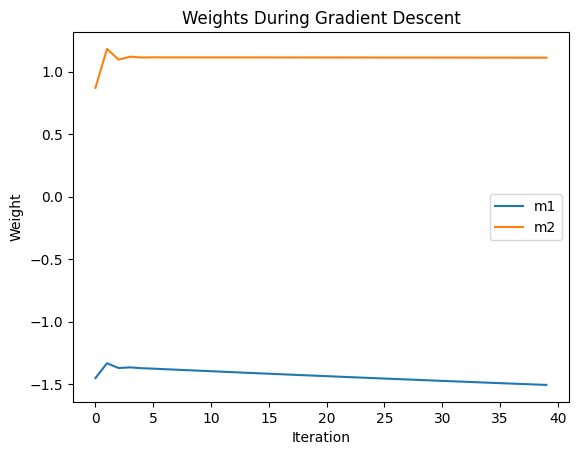

In [19]:
#===================
# plot m (weight)
#===================

m1 = [x[0][0] for x in m_history]

m2 = [x[1][0] for x in m_history]

plt.plot(m1,label="m1")

plt.plot(m2,label="m2")

plt.xlabel("Iteration")

plt.ylabel("Weight")

plt.title("Weights During Gradient Descent")

plt.legend()

plt.show()

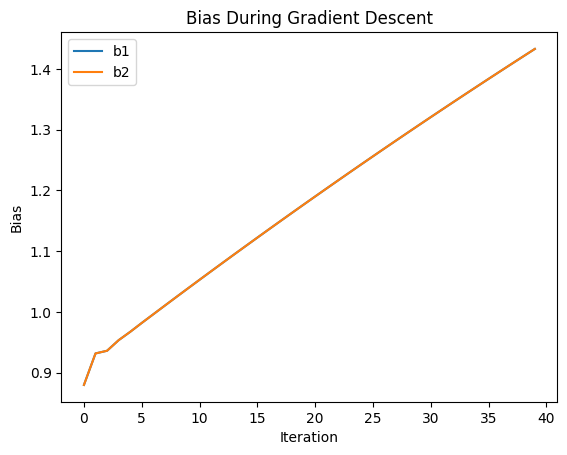

In [20]:
#=================
# Plot b (bias)
#=================

b1 = [x[0][0] for x in b_history]

b2 = [x[1][0] for x in b_history]

plt.plot(b1,label="b1")

plt.plot(b2,label="b2")

plt.xlabel("Iteration")

plt.ylabel("Bias")

plt.title("Bias During Gradient Descent")

plt.legend()

plt.show()


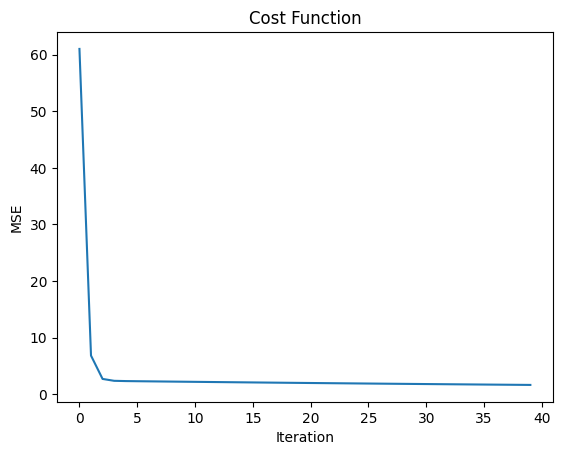

In [21]:
#================
# plot error
#================

plt.plot(cost_history)

plt.xlabel("Iteration")

plt.ylabel("MSE")

plt.title("Cost Function")

plt.show()

# Conclusion
As Gradient Descent iterates, the Mean Squared Error decreases while the weights and bias converge toward values that better fit the data.

The plots generated during training clearly illustrate the optimization process and demonstrate how Gradient Descent minimizes the cost function over successive iterations.